# Generar QR
## ¿Cómo Puedo Generar Códigos QR? (Quick Response)

Para complementar nuestro lector de códigos QR, es útil saber cómo generarlos. Aquí te mostramos diferentes métodos:

### Método 1: Con Python - Biblioteca `qrcode`

```python
import qrcode
from PIL import Image

def generar_qr_simple(contenido, nombre_archivo="mi_qr.png"):
    """Genera un código QR básico"""
    qr = qrcode.QRCode(
        version=1,  # Controla el tamaño (1 es el más pequeño)
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=10,  # Tamaño de cada "caja" del QR
        border=4,     # Grosor del borde
    )
    
    qr.add_data(contenido)
    qr.make(fit=True)
    
    # Crear imagen
    img = qr.make_image(fill_color="black", back_color="white")
    img.save(nombre_archivo)
    print(f"QR guardado como: {nombre_archivo}")

# Ejemplos de uso
generar_qr_simple("¡Hola, soy un código QR!", "ejemplos/texto_simple.png")
generar_qr_simple("https://www.python.org", "ejemplos/web_python.png")
generar_qr_simple("mailto:profesor@universidad.edu", "ejemplos/email_contacto.png")
generar_qr_simple("tel:695460198", "ejemplos/llamada_telefono.png")
generar_qr_simple("https://wa.me/34695460198", "ejemplos/enviar_whatsapp.png")
```
```

**Instalación:**
```bash
pip install qrcode[pil]
```

### Método 2: QR Personalizado con Colores

```python
import qrcode
from PIL import Image

def generar_qr_personalizado(contenido, archivo="qr_custom.png"):
    """Genera un QR con colores personalizados"""
    qr = qrcode.QRCode(
        version=3,
        error_correction=qrcode.constants.ERROR_CORRECT_H,  # Alta corrección
        box_size=8,
        border=4,
    )
    
    qr.add_data(contenido)
    qr.make(fit=True)
    
    # QR con colores personalizados
    img = qr.make_image(fill_color="darkblue", back_color="lightblue")
    img.save(archivo)
    return img

# Crear QR para pruebas del detector
qr_test = generar_qr_personalizado("Datos de prueba para el detector", "test_detector.png")
```

### Método 3: QR con Logo Integrado

```python
import qrcode
from PIL import Image, ImageDraw

def generar_qr_con_logo(contenido, logo_path, archivo="qr_logo.png"):
    """Genera un QR con logo en el centro"""
    qr = qrcode.QRCode(
        version=5,
        error_correction=qrcode.constants.ERROR_CORRECT_H,  # Necesario para logos
        box_size=8,
        border=4,
    )
    
    qr.add_data(contenido)
    qr.make(fit=True)
    
    # Crear imagen base del QR
    qr_img = qr.make_image(fill_color="black", back_color="white")
    
    # Abrir y redimensionar logo
    logo = Image.open(logo_path)
    logo_size = qr_img.size[0] // 5  # Logo será 1/5 del tamaño del QR
    logo = logo.resize((logo_size, logo_size), Image.Resampling.LANCZOS)
    
    # Calcular posición central
    pos = ((qr_img.size[0] - logo_size) // 2,
           (qr_img.size[1] - logo_size) // 2)
    
    # Pegar logo en el QR
    qr_img.paste(logo, pos)
    qr_img.save(archivo)
    
    return qr_img
```

### Tipos de Contenido para QR

```python
# Ejemplos de diferentes tipos de contenido

# 1. Texto simple
contenido_texto = "¡Bienvenidos al curso de Computer Vision!"

# 2. URL web
contenido_web = "https://opencv.org"

# 3. Email con asunto
contenido_email = "mailto:estudiante@universidad.edu?subject=Consulta CV"

# 4. SMS
contenido_sms = "sms:+34666123456?body=Hola profesor"

# 5. WiFi (formato especial)
contenido_wifi = "WIFI:T:WPA;S:MiRed;P:mipassword;;"

# 6. Coordenadas GPS
contenido_gps = "geo:40.7128,-74.0060?q=Nueva York"

# 7. Tarjeta de contacto (vCard)
contenido_vcard = """BEGIN:VCARD
VERSION:3.0
FN:Profesor Computer Vision
ORG:Universidad
EMAIL:cv.profesor@uni.edu
TEL:+34-666-123-456
END:VCARD"""

# Generar todos los QR de ejemplo
ejemplos = [
    (contenido_texto, "qr_texto.png"),
    (contenido_web, "qr_web.png"),
    (contenido_email, "qr_email.png"),
    (contenido_wifi, "qr_wifi.png"),
    (contenido_gps, "qr_gps.png"),
    (contenido_vcard, "qr_contacto.png")
]

for contenido, archivo in ejemplos:
    generar_qr_simple(contenido, archivo)
```

### Generadores Online Recomendados

Si prefieres no programar, puedes usar generadores web:

1. **QR Code Generator** - qr-code-generator.com
2. **QRStuff** - qrstuff.com  
3. **GoQR** - goqr.me
4. **QRCode Monkey** - qrcode-monkey.com

### Aplicaciones Móviles

- **Android**: QR & Barcode Scanner, QR Code Generator
- **iOS**: QR Reader, Quick Scan
- **Multiplataforma**: Google Lens (detección automática)

### Script Completo para Generar QRs de Prueba

```python
import qrcode
import os

def crear_qrs_para_practica():
    """Crea varios QR para probar nuestro detector"""
    
    # Crear directorio si no existe
    os.makedirs("qr_ejemplos", exist_ok=True)
    
    ejemplos_practica = {
        "simple.png": "Texto de prueba simple",
        "web.png": "https://python.org",
        "numero.png": "123456789",
        "email.png": "mailto:test@example.com",
        "multilinea.png": "Línea 1\nLínea 2\nLínea 3",
        "caracteres.png": "¡Hola! ñáéíóú @#$%&",
        "largo.png": "Este es un texto mucho más largo para probar cómo se comporta nuestro detector con códigos QR que contienen más información y ver si puede manejar correctamente el contenido extenso."
    }
    
    for archivo, contenido in ejemplos_practica.items():
        qr = qrcode.QRCode(version=1, box_size=10, border=5)
        qr.add_data(contenido)
        qr.make(fit=True)
        
        img = qr.make_image(fill_color="black", back_color="white")
        img.save(f"qr_ejemplos/{archivo}")
        print(f"✓ Creado: {archivo}")
    
    print("\n¡QRs de práctica creados! Úsalos para probar tu detector.")

# Ejecutar creación de ejemplos
crear_qrs_para_practica()
```

### Ejercicio Práctico: Generador + Detector

Combina ambos programas para crear un sistema completo:

1. **Genera QRs** con diferentes contenidos
2. **Úsalos para probar** tu detector
3. **Verifica** que la información se lee correctamente
4. **Experimenta** con diferentes tamaños y colores

### Tips para QRs Legibles

- **Contraste alto**: Fondo claro, código oscuro
- **Tamaño adecuado**: Mínimo 2x2 cm para impresión
- **Distancia**: El QR debe ser 1/10 de la distancia de lectura
- **Superficie plana**: Evitar superficies curvas o arrugadas
- **Iluminación uniforme**: Sin sombras ni reflejos

## Troubleshooting Común

- **Error de cámara**: Verificar que no esté siendo usada por otra aplicación
- **Dependencias**: Instalar `zbar` en sistemas Linux: `sudo apt-get install libzbar0`
- **Rendimiento**: Para cámaras lentas, aumentar el valor en `waitKey()`
- **Detección fallida**: Asegurar buena iluminación y enfoque del código QR

## Conclusiones

Este proyecto demuestra conceptos fundamentales de Computer Vision:
- Captura de video en tiempo real
- Detección de patrones específicos
- Procesamiento de regiones de interés
- Superposición de elementos gráficos
- Interacción usuario-sistema

In [1]:
import qrcode
from PIL import Image

def generar_qr_simple(contenido, nombre_archivo="mi_qr.png"):
    """Genera un código QR básico"""
    qr = qrcode.QRCode(
        version=1,  # Controla el tamaño (1 es el más pequeño)
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=10,  # Tamaño de cada "caja" del QR
        border=4,     # Grosor del borde
    )
    
    qr.add_data(contenido)
    qr.make(fit=True)
    
    # Crear imagen
    img = qr.make_image(fill_color="black", back_color="white")
    img.save(nombre_archivo)
    print(f"QR guardado como: {nombre_archivo}")

# Ejemplos de uso
generar_qr_simple("¡Hola, soy un código QR!", "texto_simple.png")
generar_qr_simple("https://www.python.org", "web_python.png")
generar_qr_simple("mailto:profesor@universidad.edu", "email_contacto.png")

QR guardado como: texto_simple.png
QR guardado como: web_python.png
QR guardado como: email_contacto.png


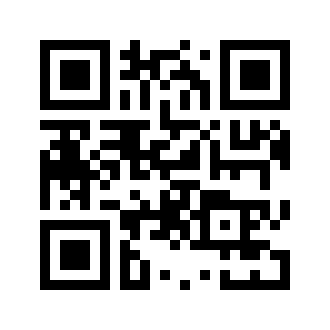

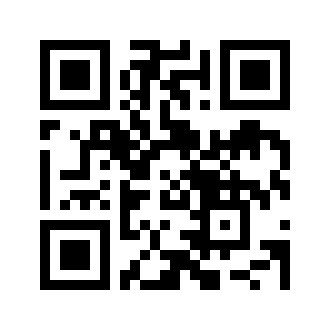

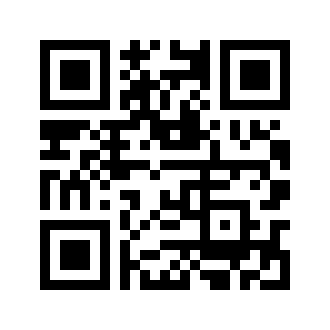

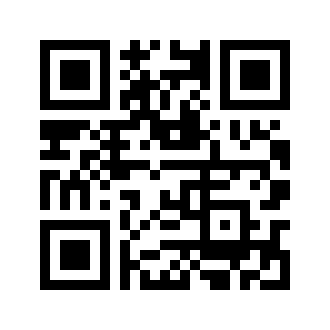

In [2]:
import qrcode
from PIL import Image
from IPython.display import display

def generar_qr_simple(contenido):
    """Genera y muestra un código QR básico en el notebook"""
    qr = qrcode.QRCode(
        version=1,  # Tamaño (1 = pequeño)
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=10,
        border=4,
    )
    
    qr.add_data(contenido)
    qr.make(fit=True)
    
    img = qr.make_image(fill_color="black", back_color="white")
    
    # Mostrar directamente en el notebook
    display(img)
    return img

# Ejemplos de uso (se mostrarán en el notebook)
generar_qr_simple("¡Hola, soy un código QR!")
generar_qr_simple("https://www.python.org")
generar_qr_simple("mailto:profesor@universidad.edu")
